In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
positive_reviews = [
    "The car engine is very smooth and powerful",
    "Excellent mileage and comfortable seats",
    "The braking system works perfectly",
    "Very good driving experience",
    "Amazing pickup and low fuel consumption",
    "The suspension is comfortable on rough roads",
    "The steering feels light and responsive",
    "Very satisfied with the vehicle performance",
    "The AC cools the cabin quickly",
    "The dashboard design looks premium"
]
negative_reviews = [
    "Engine makes a loud noise while driving",
    "Very poor mileage and high fuel consumption",
    "Brake performance is disappointing",
    "Seats are uncomfortable for long drives",
    "The suspension is too hard",
    "The steering vibrates at high speed",
    "Engine overheats after long driving",
    "The battery drains very quickly",
    "Too much vibration inside the cabin",
    "Frequent maintenance problems with this car"
]

reviews, labels = [], []
for _ in range(500):
    reviews.append(random.choice(positive_reviews)); labels.append(1)
for _ in range(500):
    reviews.append(random.choice(negative_reviews)); labels.append(0)

feedback_df = pd.DataFrame({"Review": reviews, "Sentiment": labels})
display(feedback_df.head())
print(feedback_df["Sentiment"].value_counts())

,Review,Sentiment
0,Excellent mileage and comfortable seats,1
1,The car engine is very smooth and powerful,1
2,Amazing pickup and low fuel consumption,1
3,Very good driving experience,1
4,Very good driving experience,1


Sentiment
1    500
0    500
Name: count, dtype: int64


In [3]:
VOCAB_SIZE = 2000
MAX_LENGTH = 20

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(feedback_df["Review"])
sequences = tokenizer.texts_to_sequences(feedback_df["Review"])
padded_reviews = pad_sequences(sequences, maxlen=MAX_LENGTH, padding="post")

X_train, X_test, y_train, y_test = train_test_split(
    padded_reviews, feedback_df["Sentiment"].values,
    test_size=0.20, random_state=42, stratify=feedback_df["Sentiment"].values
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (800, 20)
Testing shape: (200, 20)


In [4]:
model = Sequential([
    Embedding(VOCAB_SIZE, 32, input_length=MAX_LENGTH),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train, y_train, validation_split=0.2,
    epochs=8, batch_size=32, verbose=1
)

Epoch 1/8


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.4953 - loss: 0.6934 - val_accuracy: 0.5188 - val_loss: 0.6922
Epoch 2/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5578 - loss: 0.6889 - val_accuracy: 0.6562 - val_loss: 0.6745
Epoch 3/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9328 - loss: 0.5212 - val_accuracy: 1.0000 - val_loss: 0.2130
Epoch 4/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1176 - val_accuracy: 1.0000 - val_loss: 0.0421
Epoch 5/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0320 - val_accuracy: 1.0000 - val_loss: 0.0172
Epoch 6/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0164 - val_accuracy: 1.0000 - val_loss: 0.0105
Epoch 7/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 0.0073
Epoch 8/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 0.0055


In [5]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
probs = model.predict(X_test, verbose=0).ravel()
preds = (probs >= 0.5).astype(int)

print("Test Accuracy:", round(accuracy,3))
print("Test Loss:", round(loss,3))
print(classification_report(y_test, preds, target_names=["Negative","Positive"]))

Test Accuracy: 1.0
Test Loss: 0.006
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       100
    Positive       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



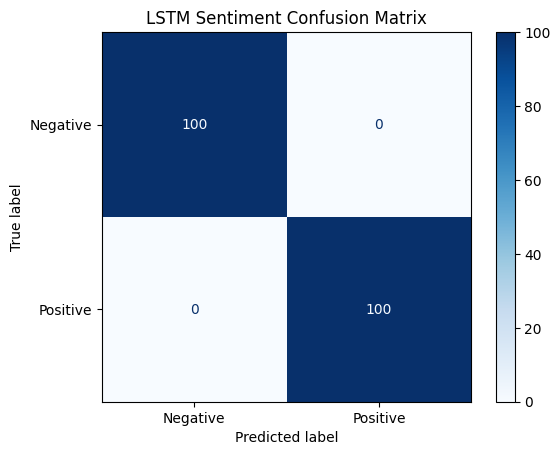

In [6]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, preds),
    display_labels=["Negative","Positive"]
).plot(cmap="Blues")
plt.title("LSTM Sentiment Confusion Matrix")
plt.show()

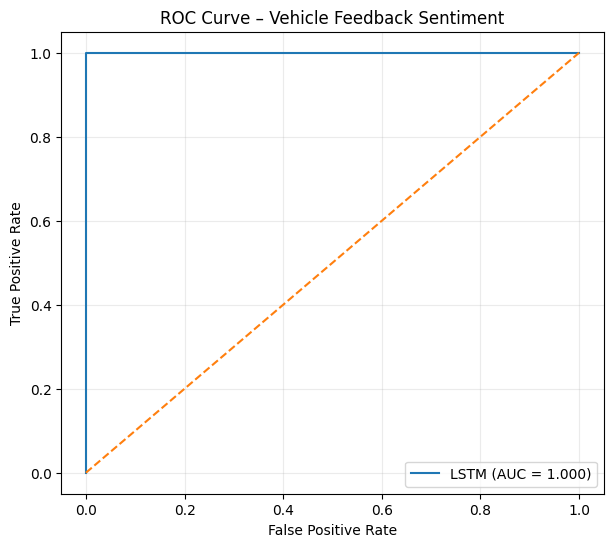

In [7]:
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"LSTM (AUC = {auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Vehicle Feedback Sentiment")
plt.legend()
plt.grid(alpha=.25)
plt.show()

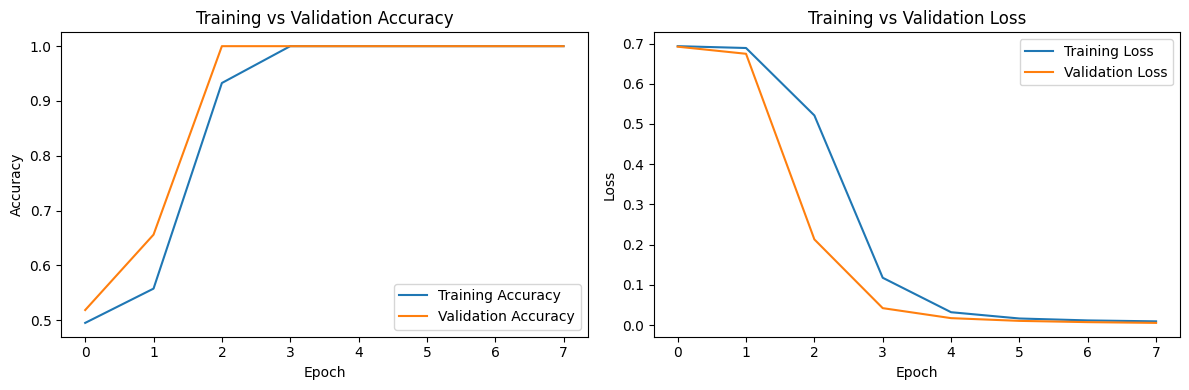

In [8]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout()
plt.show()

In [9]:
new_reviews = [
    "The engine performance is excellent and mileage is very good",
    "The battery drains quickly and the engine overheats",
    "Comfortable seats and smooth steering",
    "Very poor braking and high maintenance cost"
]

new_seq = tokenizer.texts_to_sequences(new_reviews)
new_pad = pad_sequences(new_seq, maxlen=MAX_LENGTH, padding="post")
new_scores = model.predict(new_pad, verbose=0).ravel()

for review, score in zip(new_reviews, new_scores):
    sentiment = "Positive" if score >= 0.5 else "Negative"
    confidence = score if score >= 0.5 else 1-score
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("Confidence:", round(float(confidence),3))
    print("-"*60)

Review: The engine performance is excellent and mileage is very good
Predicted Sentiment: Positive
Confidence: 0.996
------------------------------------------------------------
Review: The battery drains quickly and the engine overheats
Predicted Sentiment: Negative
Confidence: 0.993
------------------------------------------------------------
Review: Comfortable seats and smooth steering
Predicted Sentiment: Positive
Confidence: 0.996
------------------------------------------------------------
Review: Very poor braking and high maintenance cost
Predicted Sentiment: Negative
Confidence: 0.993
------------------------------------------------------------
